# Diemtigen XAI pipeline: 3-segment features + EBM only

This single notebook replaces the previous multi-notebook workflow.
It:
1. builds the **3-segment signal features** dataset,
2. trains/evaluates an **Explainable Boosting Machine (EBM)**,
3. provides native EBM interpretation plots and summaries.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from interpret.glassbox import ExplainableBoostingClassifier


In [3]:
data_root = Path('diemtigen_data')
h5_path = data_root / 'events_mainshocks_foreshocks_aftershocks_15sec_23days.h5'
info_path = data_root / 'info_h5_events_mainshocks_foreshocks_aftershocks_15sec_23days.csv'
features_path = data_root / 'data_features.csv'

info = pd.read_csv(info_path)
label_map = {'foreshock': 0, 'aftershock': 1}
info_fa = info[info['event_type'].isin(label_map)].copy().reset_index(drop=True)
info_fa['label'] = info_fa['event_type'].map(label_map)

info_fa[['event_id', 'event_type', 'label']].head()


,event_id,event_type,label
0,20140417015156,foreshock,0
1,20140417023407,foreshock,0
2,20140417030217,foreshock,0
3,20140417030538,foreshock,0
4,20140417030638,foreshock,0


In [4]:
def rms(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x * x))) if x.size else np.nan

def energy(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x * x)) if x.size else np.nan

def peak_abs(x):
    x = np.asarray(x, dtype=float)
    return float(np.max(np.abs(x))) if x.size else np.nan

def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return np.nan
    s = np.sign(x)
    s[s == 0] = 1
    return float(np.mean(s[:-1] != s[1:]))

def safe_ratio(a, b):
    if b is None or np.isnan(b) or abs(b) < 1e-12:
        return np.nan
    return float(a / b)


In [5]:
SEGMENTS = {
    'noise': (0.0, 1.0),     # pre-P noise
    'p': (1.0, 4.0),         # P arrival + early energy
    'coda': (4.0, 15.0),     # scattered + decay
}
CHANNELS = {'E': 'HHE', 'N': 'HHN', 'Z': 'HHZ'}


def get_event_traces(h5f, event_id: str):
    g = h5f[str(event_id)]
    tr = g['traces']
    keys = list(tr.keys())
    sr = float(tr[keys[0]].attrs.get('sampling_rate', np.nan))

    out = {}
    for comp, chan in CHANNELS.items():
        k = [kk for kk in keys if kk.endswith(chan)]
        out[comp] = np.array(tr[k[0]][:]) if k else None
    return out, sr


In [6]:
rows = []

with h5py.File(h5_path, 'r') as h5f:
    for _, r in info_fa.iterrows():
        eid = str(r['event_id'])
        if eid not in h5f:
            continue

        traces, sr = get_event_traces(h5f, eid)
        if any(traces[c] is None for c in CHANNELS):
            continue

        L = min(traces['E'].size, traces['N'].size, traces['Z'].size)
        for c in traces:
            traces[c] = traces[c][:L].astype(float)

        base = {
            'event_id': eid,
            'label': int(r['label']),
            'event_type': r['event_type'],
            'sampling_rate': sr,
            'npts': L,
        }

        feat = dict(base)
        for seg_name, (t0, t1) in SEGMENTS.items():
            i0, i1 = int(round(t0 * sr)), int(round(t1 * sr))
            for comp in ['E', 'N', 'Z']:
                x = traces[comp][i0:i1]
                prefix = f'{comp}_{seg_name}'
                feat[f'{prefix}_rms'] = rms(x)
                feat[f'{prefix}_energy'] = energy(x)
                feat[f'{prefix}_peak_abs'] = peak_abs(x)
                feat[f'{prefix}_zcr'] = zero_crossing_rate(x)

        for comp in ['E', 'N', 'Z']:
            feat[f'{comp}_snr_proxy'] = safe_ratio(feat[f'{comp}_p_rms'], feat[f'{comp}_noise_rms'])
            feat[f'{comp}_coda_to_p_energy'] = safe_ratio(feat[f'{comp}_coda_energy'], feat[f'{comp}_p_energy'])

        rows.append(feat)


df_features = pd.DataFrame(rows)
df_features.to_csv(features_path, index=False)
print('Saved:', features_path, 'shape=', df_features.shape)
df_features.head()


Saved: diemtigen_data\data_features.csv shape= (2341, 47)


,event_id,label,event_type,sampling_rate,npts,E_noise_rms,E_noise_energy,E_noise_peak_abs,E_noise_zcr,N_noise_rms,...,Z_coda_rms,Z_coda_energy,Z_coda_peak_abs,Z_coda_zcr,E_snr_proxy,E_coda_to_p_energy,N_snr_proxy,N_coda_to_p_energy,Z_snr_proxy,Z_coda_to_p_energy
0,20140417015156,0,foreshock,120.0,1801,57.349223,394672.0,115.0,0.294118,59.803707,...,62.232525,5112211.0,138.0,0.048522,0.813419,5.958638,0.473612,12.927494,5.131093,3.196580
1,20140417023407,0,foreshock,120.0,1801,41.918472,210859.0,89.0,0.495798,85.411601,...,96.679900,12338044.0,232.0,0.022745,1.772160,4.228481,0.798926,6.191147,1.191125,1.723482
2,20140417030217,0,foreshock,120.0,1801,113.602377,1548660.0,186.0,0.042017,29.752451,...,71.881052,6820289.0,153.0,0.034117,0.769819,0.781536,1.151989,8.365305,1.697469,9.640666
3,20140417030538,0,foreshock,120.0,1801,97.327026,1136706.0,156.0,0.000000,39.297901,...,53.179328,3733014.0,115.0,0.035633,0.721438,4.390779,0.536043,7.347531,0.612373,1.947691
4,20140417030638,0,foreshock,120.0,1801,35.017734,147149.0,92.0,0.546218,68.543052,...,86.455458,9866401.0,179.0,0.026535,1.014414,14.317464,0.964974,1.400059,0.532890,8.886296


## Train/Evaluate EBM (only model)



In [7]:
df = pd.read_csv(features_path)

y = df['label'].astype(int).values
X = df.drop(columns=['event_id', 'label', 'event_type']).copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

ebm = ExplainableBoostingClassifier(random_state=0, interactions=0)
ebm.fit(X_train, y_train)

proba = ebm.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print({
    'accuracy': accuracy_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'roc_auc': roc_auc_score(y_test, proba),
})
print(classification_report(y_test, pred, target_names=['foreshock', 'aftershock']))


{'accuracy': 0.55863539445629, 'f1': 0.5490196078431373, 'roc_auc': 0.5891980360065466}
              precision    recall  f1-score   support

   foreshock       0.56      0.58      0.57       234
  aftershock       0.56      0.54      0.55       235

    accuracy                           0.56       469
   macro avg       0.56      0.56      0.56       469
weighted avg       0.56      0.56      0.56       469



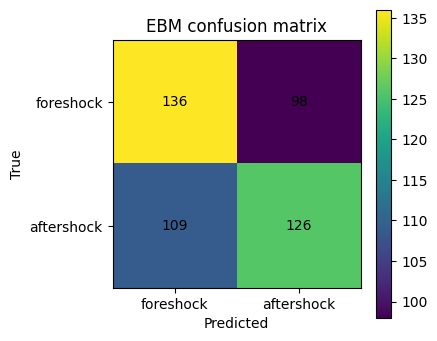

In [8]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation='nearest')
plt.title('EBM confusion matrix')
plt.colorbar()
plt.xticks([0, 1], ['foreshock', 'aftershock'])
plt.yticks([0, 1], ['foreshock', 'aftershock'])
plt.xlabel('Predicted')
plt.ylabel('True')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.show()


## EBM interpretation (native)


In [9]:
def ebm_top_importances(model, topk=20):
    ge = model.explain_global().data()
    out = pd.DataFrame({'feature': ge['names'], 'importance': ge['scores']})
    return out.sort_values('importance', ascending=False).head(topk)

top = ebm_top_importances(ebm, topk=25)
top.head(10)


,feature,importance
17,E_p_zcr,0.029587
29,E_coda_zcr,0.028909
38,E_snr_proxy,0.028236
26,E_coda_rms,0.028149
31,N_coda_energy,0.027457
30,N_coda_rms,0.027357
27,E_coda_energy,0.027026
41,N_coda_to_p_energy,0.022630
42,Z_snr_proxy,0.020408
40,N_snr_proxy,0.019694


In [10]:
import re

def segment_from_feature(name):
    if '_noise_' in name:
        return 'noise'
    if '_p_' in name:
        return 'p'
    if '_coda_' in name:
        return 'coda'
    return 'cross_segment'

def channel_from_feature(name):
    m = re.match(r'^([ENZ])_', name)
    return m.group(1) if m else 'derived'

summary = top.copy()
summary['segment'] = summary['feature'].map(segment_from_feature)
summary['channel'] = summary['feature'].map(channel_from_feature)
summary.groupby(['segment', 'channel'], as_index=False)['importance'].sum().sort_values('importance', ascending=False)


,segment,channel,importance
1,coda,N,0.087880
0,coda,E,0.084084
6,noise,E,0.061031
9,p,E,0.048028
2,coda,Z,0.047681
10,p,N,0.038844
11,p,Z,0.030782
3,cross_segment,E,0.028236
5,cross_segment,Z,0.020408
4,cross_segment,N,0.019694
